# Intercept grain size estimation

Now, we shall find the intercept grain sizes and plot them

In [1]:
from upxo.ggrowth.mcgs import mcgs
import matplotlib.pyplot as plt

C:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\Users\rg5749\AppData\Local\miniforge3\envs\shark\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [2]:
pxt = mcgs(study='independent', input_dashboard='demo_3d_02.xls')
pxt.simulate(verbose=False)
tslice = 90
gstslice = pxt.gs[tslice]
gstslice.char_morphology_of_grains(label_str_order=1,
                                   find_grain_voxel_locs=True,
                                   find_spatial_bounds_of_grains=True,
                                   force_compute=True)
gstslice.set_mprops(volnv=True, eqdia=False,
                    eqdia_base_size_spec='volnv',
                    arbbox=False, arbbox_fmt='gid_dict',
                    arellfit=False, arellfit_metric='max',
                    arellfit_calculate_efits=False,
                    arellfit_efit_routine=1,
                    arellfit_efit_regularize_data=False,
                    solidity=False, sol_nan_treatment='replace',
                    sol_inf_treatment='replace',
                    sol_nan_replacement=-1, sol_inf_replacement=-1)

c:\development\m2matmod\upxo_packaged\upxo_private\src\upxo\interfaces\user_inputs
c:\development\m2matmod\upxo_packaged\upxo_private\src\upxo\interfaces\user_inputs\demo_3d_02.xls
Algo_hops details
(('300a', 100),)
[False]





 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 60.0, 1.0
     ymin, ymax, yinc: 0.0, 60.0, 1.0
     zmin, zmax, zinc: 0.0, 60.0, 1.0
     No. of states: 16
     Dimensionality: 3
     Algorithm: 300a 





Using ALG-300a
////////////////////////////////
Initiating grain growth
----------------------------------------
GS temporal slice 0 stored
GS temporal slice 1 stored
GS temporal slice 2 stored
GS temporal slice 3 stored
GS temporal slice 4 stored
GS temporal slice 5 stored
GS temporal slice 6 stored
GS temporal slice 7 stored
GS temporal slice 8 stored
GS temporal slice 9 stored
GS temporal slice 10 stored
GS temporal slice 11 stored
GS temporal slice 12 stored
GS temporal slice 13 stored
GS temporal slice 14 stored
GS temporal slice 15 store

In [3]:
igs_rshuffle = []
nshuffles = 1000
for i in range(nshuffles):
    igs = gstslice.get_igs_along_lines(metric='mean', minimum=True, maximum=True,
                                 std=True, variance=True, lines_gen_method=1,
                                 lines_kwargs1={'plane': 'z',
                                                'start_skip1': 0, 'start_skip2': 0,
                                                'incr1': 5, 'incr2': 5,
                                                'inclination': 'random',
                                                'inclination_extent': 0,
                                                'shift_seperately': True,
                                                'shift_starts': True,
                                                'shift_ends': True,
                                                'start_shift': 5, 'end_shift': 1})
    igs_rshuffle.append(igs['igs'])
    if i % 100 == 0:
        print(f'Shuffling count: {i}')

Shuffling count: 0
Shuffling count: 100
Shuffling count: 200
Shuffling count: 300
Shuffling count: 400
Shuffling count: 500
Shuffling count: 600
Shuffling count: 700
Shuffling count: 800
Shuffling count: 900


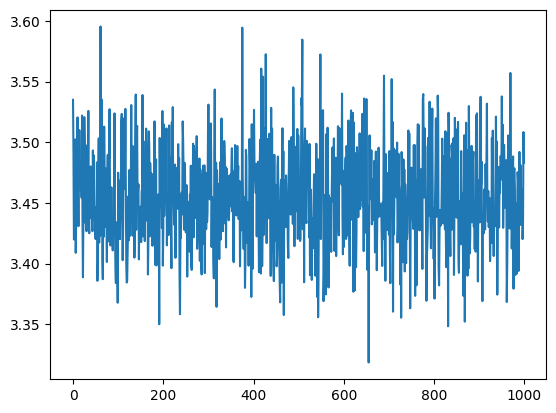

In [4]:
plt.plot(range(nshuffles), igs_rshuffle)